# Keystroke Dynamics — CMU Benchmark Walkthrough

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EngDawood/cmu-keystroke-dataset/blob/main/notebooks/keystroke_dynamics_walkthrough.ipynb)


End-to-end notebook covering everything in this repo: data loading, the scaled-Manhattan
matcher, all four benchmark detectors, EER evaluation, the full Killourhy & Maxion (DSN 2009)
benchmark loop, results, and plots.

Reference: K. Killourhy and R. Maxion, "Comparing Anomaly-Detection Algorithms for Keystroke
Dynamics", DSN 2009. (http://www.cs.cmu.edu/~keystroke/)

Run from the repo root with the `keystroke-dynamics` environment active (`uv sync`).

In [1]:
import os
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Clone the repo (dataset + installable package) and cd into notebooks/ so the
    # relative "../src" and "../data" paths below resolve exactly as they do locally.
    repo_dir = "/content/cmu-keystroke-dataset"
    if not os.path.exists(repo_dir):
        !git clone -q https://github.com/EngDawood/cmu-keystroke-dataset.git {repo_dir}
    os.chdir(os.path.join(repo_dir, "notebooks"))
    !pip install -q numpy pandas scikit-learn matplotlib

sys.path.insert(0, os.path.join(os.getcwd(), "..", "src") if os.path.basename(os.getcwd()) == "notebooks" else "src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve

from keystroke_dynamics import DETECTORS, compute_eer
from keystroke_dynamics.model import build_profile, score

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## 1. Download the dataset

The CMU Keystroke Dynamics Benchmark files are fetched directly from
http://www.cs.cmu.edu/~keystroke/ into `data/` if not already present locally
(the repo already ships them, so this is a no-op by default).

In [2]:
import urllib.request

DATA_DIR = os.path.join("..", "data") if os.path.basename(os.getcwd()) == "notebooks" else "data"
os.makedirs(DATA_DIR, exist_ok=True)

BASE_URL = "https://www.cs.cmu.edu/~keystroke/"
DATASET_FILES = ["DSL-StrongPasswordData.txt", "DSL-StrongPasswordData.csv", "DSL-StrongPasswordData.xls"]

for filename in DATASET_FILES:
    dest = os.path.join(DATA_DIR, filename)
    if os.path.exists(dest):
        print(f"Already have {filename}, skipping download.")
        continue
    url = BASE_URL + filename
    print(f"Downloading {url} -> {dest}")
    urllib.request.urlretrieve(url, dest)
print("Dataset files ready in", DATA_DIR)

Already have DSL-StrongPasswordData.txt, skipping download.
Already have DSL-StrongPasswordData.csv, skipping download.
Already have DSL-StrongPasswordData.xls, skipping download.
Dataset files ready in ../data


## 2. Load the dataset

51 subjects x 400 repetitions of typing the password `.tie5Roanl`, 31 timing features per row
(hold times, keydown-keydown and keyup-keydown latencies).

In [3]:
DATA_DIR = os.path.join("..", "data") if os.path.basename(os.getcwd()) == "notebooks" else "data"
CSV_PATH = os.path.join(DATA_DIR, "DSL-StrongPasswordData.csv")


def load_dataset(csv_path: str):
    """Return {subject: feature matrix ordered by (sessionIndex, rep)}."""
    df = pd.read_csv(csv_path)
    feature_cols = df.columns[3:]  # the 31 timing features
    assert len(feature_cols) == 31, f"expected 31 features, got {len(feature_cols)}"
    df = df.sort_values(["subject", "sessionIndex", "rep"]).reset_index(drop=True)
    subjects = sorted(df["subject"].unique())
    data = {s: df.loc[df["subject"] == s, feature_cols].to_numpy(dtype=float)
            for s in subjects}
    return df, subjects, data, list(feature_cols)


df, subjects, data, feature_cols = load_dataset(CSV_PATH)
print(f"Loaded {len(df)} rows, {len(subjects)} subjects, {len(feature_cols)} timing features.")
df.head()

Loaded 20400 rows, 51 subjects, 31 timing features.


,subject,sessionIndex,rep,H.period,DD.period.t,UD.period.t,H.t,DD.t.i,UD.t.i,H.i,...,H.a,DD.a.n,UD.a.n,H.n,DD.n.l,UD.n.l,H.l,DD.l.Return,UD.l.Return,H.Return
0,s002,1,1,0.1491,0.3979,0.2488,0.1069,0.1674,0.0605,0.1169,...,0.1349,0.1484,0.0135,0.0932,0.3515,0.2583,0.1338,0.3509,0.2171,0.0742
1,s002,1,2,0.1111,0.3451,0.2340,0.0694,0.1283,0.0589,0.0908,...,0.1412,0.2558,0.1146,0.1146,0.2642,0.1496,0.0839,0.2756,0.1917,0.0747
2,s002,1,3,0.1328,0.2072,0.0744,0.0731,0.1291,0.0560,0.0821,...,0.1621,0.2332,0.0711,0.1172,0.2705,0.1533,0.1085,0.2847,0.1762,0.0945
3,s002,1,4,0.1291,0.2515,0.1224,0.1059,0.2495,0.1436,0.1040,...,0.1457,0.1629,0.0172,0.0866,0.2341,0.1475,0.0845,0.3232,0.2387,0.0813
4,s002,1,5,0.1249,0.2317,0.1068,0.0895,0.1676,0.0781,0.0903,...,0.1312,0.1582,0.0270,0.0884,0.2517,0.1633,0.0903,0.2517,0.1614,0.0818


## 3. Explore the features

Quick look at a single subject's timing distributions to get a feel for the data before
running the benchmark.

Subject s002: 400 repetitions x 31 features


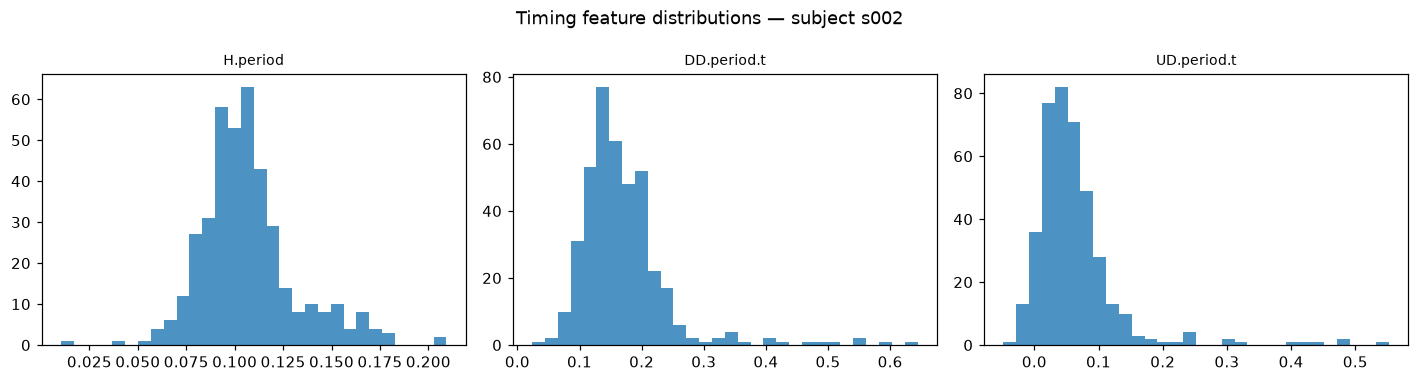

In [4]:
example_subject = subjects[0]
example = data[example_subject]
print(f"Subject {example_subject}: {example.shape[0]} repetitions x {example.shape[1]} features")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col in zip(axes, feature_cols[:3]):
    idx = feature_cols.index(col)
    ax.hist(example[:, idx], bins=30, color="tab:blue", alpha=0.8)
    ax.set_title(col, fontsize=9)
fig.suptitle(f"Timing feature distributions — subject {example_subject}")
plt.tight_layout()
plt.show()

## 4. The scaled-Manhattan matcher (`keystroke_dynamics.model`)

Dataset-agnostic profile + scoring functions, reused both by this offline benchmark and (per
the README) by a live verification backend.

- `build_profile(samples)` -> per-feature mean and mean-absolute-deviation (MAD floored to
  avoid divide-by-zero).
- `score(profile, sample)` -> scaled Manhattan distance; **lower = more genuine**.

In [5]:
N_TRAIN = 200        # first 200 repetitions -> enrollment
N_IMPOSTOR_REPS = 5   # first 5 repetitions of every other subject

train_demo = example[:N_TRAIN]
genuine_test_demo = example[N_TRAIN:]
impostor_test_demo = np.vstack([data[o][:N_IMPOSTOR_REPS] for o in subjects if o != example_subject])

profile_demo = build_profile(train_demo)
print("mean shape:", profile_demo["mean"].shape, " mad shape:", profile_demo["mad"].shape)

genuine_scores_demo = np.array([score(profile_demo, x) for x in genuine_test_demo])
impostor_scores_demo = np.array([score(profile_demo, x) for x in impostor_test_demo])
print(f"Genuine score  mean={genuine_scores_demo.mean():.2f}  std={genuine_scores_demo.std():.2f}")
print(f"Impostor score mean={impostor_scores_demo.mean():.2f}  std={impostor_scores_demo.std():.2f}")

mean shape: (31,)  mad shape: (31,)
Genuine score  mean=43.20  std=15.42
Impostor score mean=104.46  std=81.27


## 5. All four benchmark detectors (`keystroke_dynamics.detectors`)

`DETECTORS` maps a name to a `(train, test) -> scores` function. Scaled Manhattan delegates to
`model.py`; the other three are self-contained reference implementations from the paper.

In [6]:
list(DETECTORS.keys())

['Scaled Manhattan',
 'Nearest Neighbor (Mahalanobis)',
 'Manhattan',
 'Euclidean']

In [7]:
for name, detector in DETECTORS.items():
    g = detector(train_demo, genuine_test_demo)
    i = detector(train_demo, impostor_test_demo)
    print(f"{name:<34} genuine mean={g.mean():8.2f}   impostor mean={i.mean():8.2f}")

Scaled Manhattan                   genuine mean=   43.20   impostor mean=  104.46
Nearest Neighbor (Mahalanobis)     genuine mean=    5.09   impostor mean=   12.33
Manhattan                          genuine mean=    1.74   impostor mean=    4.36
Euclidean                          genuine mean=    0.51   impostor mean=    1.29


## 6. Equal Error Rate (`keystroke_dynamics.evaluation`)

`compute_eer(genuine_scores, impostor_scores)` finds the threshold where the false-accept rate
equals the false-reject rate, via linear interpolation between the two bracketing ROC points.

In [8]:
eer_demo, thr_demo = compute_eer(genuine_scores_demo, impostor_scores_demo)
print(f"Subject {example_subject} — Scaled Manhattan EER = {eer_demo:.3f} at threshold {thr_demo:.2f}")

Subject s002 — Scaled Manhattan EER = 0.240 at threshold 54.02


## 7. Full benchmark loop

Repeats the demo above for every subject and every detector — mirrors `train.py` exactly.

In [9]:
per_subject_eer = {name: [] for name in DETECTORS}
pooled_genuine, pooled_impostor = [], []
confusion = np.zeros((2, 2), dtype=int)  # [true genuine/impostor][pred accept/reject]

for subject in subjects:
    genuine_all = data[subject]
    train = genuine_all[:N_TRAIN]
    genuine_test = genuine_all[N_TRAIN:]
    impostor_test = np.vstack([data[o][:N_IMPOSTOR_REPS] for o in subjects if o != subject])

    for name, detector in DETECTORS.items():
        g = detector(train, genuine_test)
        i = detector(train, impostor_test)
        eer, thr = compute_eer(g, i)
        per_subject_eer[name].append(eer)

        if name == "Scaled Manhattan":
            pooled_genuine.append(g)
            pooled_impostor.append(i)
            confusion[0, 0] += int((g <= thr).sum())   # genuine accepted
            confusion[0, 1] += int((g > thr).sum())    # genuine rejected
            confusion[1, 0] += int((i <= thr).sum())   # impostor accepted
            confusion[1, 1] += int((i > thr).sum())    # impostor rejected

print("Benchmark complete over", len(subjects), "subjects.")

Benchmark complete over 51 subjects.


## 8. Results summary

Per-subject EER for every detector, plus mean/std compared to the published Killourhy & Maxion
(2009) numbers.

In [10]:
EXPECTED_EER = {
    "Scaled Manhattan": 0.096,
    "Nearest Neighbor (Mahalanobis)": 0.100,
    "Manhattan": 0.153,
    "Euclidean": 0.171,
}

summary = pd.DataFrame({"subject": subjects})
for name in DETECTORS:
    col = "eer_" + name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    summary[col] = per_subject_eer[name]
summary.head()

,subject,eer_scaled_manhattan,eer_nearest_neighbor_mahalanobis,eer_manhattan,eer_euclidean
0,s002,0.240,0.250,0.240,0.260
1,s003,0.140,0.210,0.192,0.188
2,s004,0.080,0.075,0.144,0.190
3,s005,0.044,0.060,0.092,0.116
4,s007,0.112,0.075,0.090,0.072


In [11]:
rows = []
for name in DETECTORS:
    eers = np.array(per_subject_eer[name])
    rows.append({
        "Detector": name,
        "Mean EER": round(eers.mean(), 3),
        "Std": round(eers.std(), 3),
        "Published (K&M 2009)": EXPECTED_EER[name],
    })
pd.DataFrame(rows)

,Detector,Mean EER,Std,Published (K&M 2009)
0,Scaled Manhattan,0.096,0.069,0.096
1,Nearest Neighbor (Mahalanobis),0.100,0.064,0.100
2,Manhattan,0.153,0.092,0.153
3,Euclidean,0.171,0.094,0.171


## 9. Plots — ROC curve and confusion matrix (scaled Manhattan)

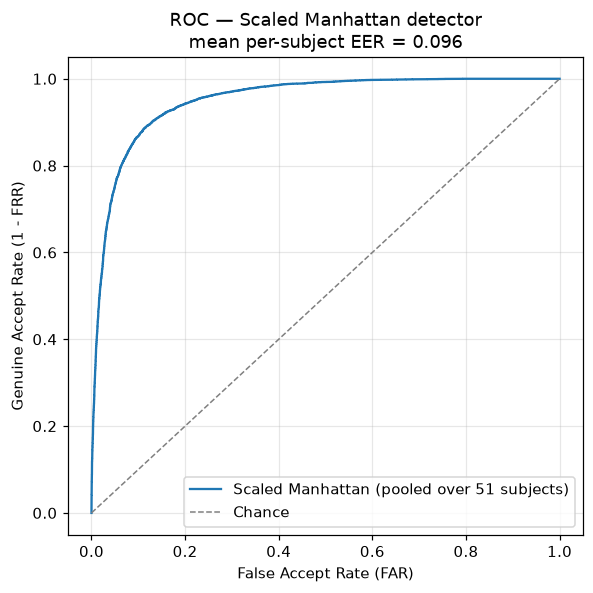

In [12]:
genuine_all_sm = np.concatenate(pooled_genuine)
impostor_all_sm = np.concatenate(pooled_impostor)
mean_eer_sm = float(np.mean(per_subject_eer["Scaled Manhattan"]))

y_true = np.concatenate([np.ones_like(genuine_all_sm), np.zeros_like(impostor_all_sm)])
far, tpr, _ = roc_curve(y_true, -np.concatenate([genuine_all_sm, impostor_all_sm]))

plt.figure(figsize=(5.5, 5.5))
plt.plot(far, tpr, color="tab:blue", label="Scaled Manhattan (pooled over 51 subjects)")
plt.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="Chance")
plt.xlabel("False Accept Rate (FAR)")
plt.ylabel("Genuine Accept Rate (1 - FRR)")
plt.title(f"ROC — Scaled Manhattan detector\nmean per-subject EER = {mean_eer_sm:.3f}")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

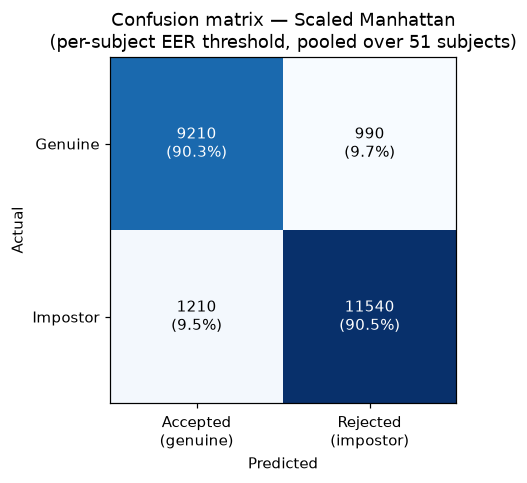

In [13]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.imshow(confusion, cmap="Blues")
ax.set_xticks([0, 1], ["Accepted\n(genuine)", "Rejected\n(impostor)"])
ax.set_yticks([0, 1], ["Genuine", "Impostor"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion matrix — Scaled Manhattan\n(per-subject EER threshold, pooled over 51 subjects)")
for r in range(2):
    for c in range(2):
        frac = confusion[r, c] / confusion[r].sum()
        ax.text(c, r, f"{confusion[r, c]}\n({frac:.1%})",
                ha="center", va="center",
                color="white" if confusion[r, c] > confusion.max() / 2 else "black")
plt.tight_layout()
plt.show()

## 10. Reusing the matcher

The scaled-Manhattan `build_profile` / `score` pair is dataset-agnostic, so it can enroll and
verify a live user the same way it evaluates the CMU benchmark above.

In [14]:
# Any (n_samples, n_features) array of timing features works, e.g. one subject's
# enrollment repetitions from this dataset:
enrollment_samples = data[subjects[0]][:N_TRAIN]
new_sample = data[subjects[0]][N_TRAIN]  # a genuine held-out repetition

profile = build_profile(enrollment_samples)
s = score(profile, new_sample)
print(f"Match score for a genuine repetition: {s:.2f}  (lower = more genuine)")

Match score for a genuine repetition: 42.47  (lower = more genuine)


## 11. Save results (optional)

Writes the same artifacts as `train.py`: `results/results_summary.csv`,
`results/roc_scaled_manhattan.png`, `results/confusion_matrix.png`.

In [15]:
SAVE_RESULTS = False  # set True to overwrite the files under results/

if SAVE_RESULTS:
    results_dir = os.path.join("..", "results") if os.path.basename(os.getcwd()) == "notebooks" else "results"
    os.makedirs(results_dir, exist_ok=True)
    summary.to_csv(os.path.join(results_dir, "results_summary.csv"), index=False)
    print(f"Saved results_summary.csv to {results_dir}/")